In [13]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
from src.structures import Slab
from configs.calculators import get_mace_calculator
from configs.calculation_settings import RELAXATION_SETTINGS
from src.structures.slab import Slab
import time

## 1. Load MACE Calculator and run calculation

In [14]:
initial_path = Path("../data/slabs/initial/Pt_111_Cu_n4_cfg000.traj")
slab = Slab.read(initial_path)

start_time = time.time()
calculator = get_mace_calculator(device="cpu")
result = slab.relax(calculator=calculator, settings=RELAXATION_SETTINGS)
print(f"Calculation Took {round(time.time() - start_time, 2)} seconds" )
print("Converged:", result.converged)
print("Steps:", result.n_steps)
print("Energy:", result.energy_eV, "eV")
print("Max force:", result.max_force_eV_A, "eV/A")

relaxed_slab = Slab(
    atoms=result.atoms,
    slab_id=slab.slab_id,
    metadata={
        **slab.metadata,
        "energy_eV": result.energy_eV,
        "converged": result.converged,
        "n_steps": result.n_steps,
        "max_force_eV_A": result.max_force_eV_A,
        "calculator": "MACE-MH-1",
        "calculator_head": "oc20_usemppbe",
    },
)

relaxed_path = Path(
    "data/slabs/relaxed"
) / f"{slab.slab_id}.traj"

relaxed_slab.write(relaxed_path)

Using Materials Project MACE for MACECalculator with /Users/iwanpavord/.cache/mace/macemh1model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/envs/dft/lib/python3.10/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/opt/anaconda3/envs/dft/lib/python3.10/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/opt/anaconda3/envs/dft/lib/python3.10/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/opt/anaconda3/envs/dft/lib/python3.10/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Calculation Took 14.07 seconds
Converged: True
Steps: 11
Energy: -324.34779795825966 eV
Max force: 0.03545919761627306 eV/A


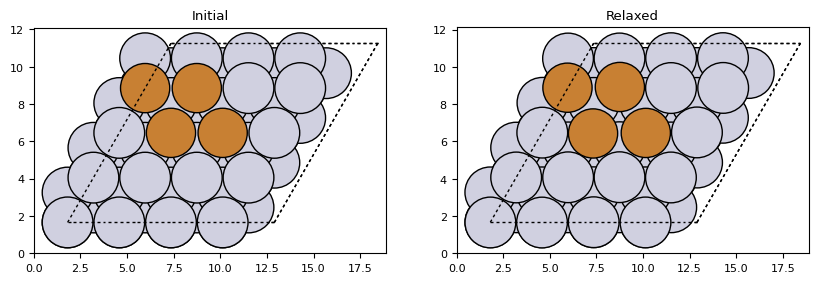

In [15]:
initial = Slab.read("../data/slabs/initial/Pt_111_Cu_n4_cfg000.traj")

relaxed = Slab.read("../data/slabs/relaxed/Pt_111_Cu_n4_cfg000.traj")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_atoms(
    initial.atoms,
    axes[0],
    rotation="0x,0y,0z",
)
axes[0].set_title("Initial")

plot_atoms(
    relaxed.atoms,
    axes[1],
    rotation="0x,0y,0z",
)
axes[1].set_title("Relaxed")

plt.show()

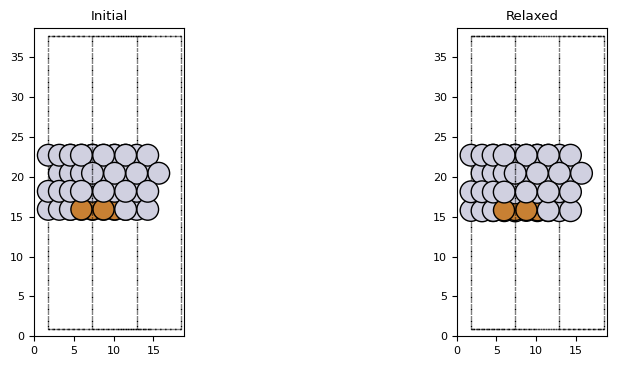

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_atoms(
    initial.atoms,
    axes[0],
    rotation="90x,0y,0z"
)
axes[0].set_title("Initial")

plot_atoms(
    relaxed.atoms,
    axes[1],
    rotation="90x,0y,0z"
)
axes[1].set_title("Relaxed")

plt.show()

In [17]:
import numpy as np

displacements = (relaxed.atoms.positions - initial.atoms.positions)
distances = np.linalg.norm(displacements, axis=1,)

print("Largest displacement:", distances.max(), "A")

Largest displacement: 0.21098261946029026 A
